Importing Library

In [105]:
import pandas as pd
import numpy as np  

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot

In [106]:
df=pd.read_csv("D:/Python_rnw/one/supervised learning/Practical Exam/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [108]:
df.shape

(1460, 81)

In [109]:
print("Statistical Summary of the Dataset: ")
df.describe()

Statistical Summary of the Dataset: 


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [110]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [111]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Numerical Columns :", len(numerical_cols))
print("Number of Categorical Columns :", len(categorical_cols))

Number of Numerical Columns : 38
Number of Categorical Columns : 43


In [112]:
missing_values = df.isnull().sum()

missing_columns = missing_values[missing_values > 0]

print("Columns with Missing Values:")
print(missing_columns)

print("\nTotal Columns with Missing Values:", len(missing_columns))

Columns with Missing Values:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Total Columns with Missing Values: 19


In [113]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [114]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

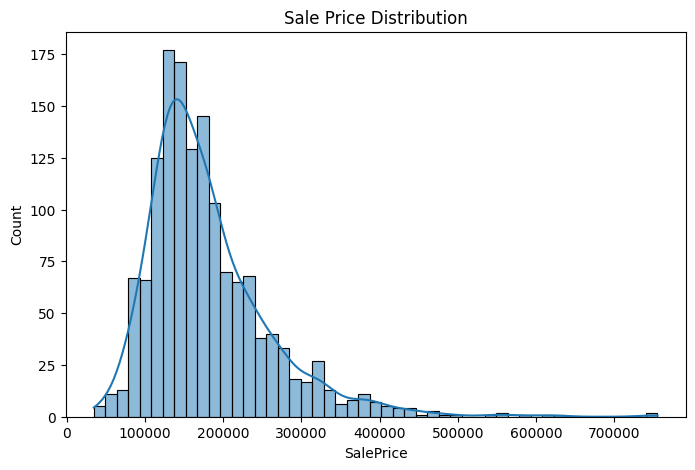

In [115]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)

plt.title("Sale Price Distribution")
plt.show()

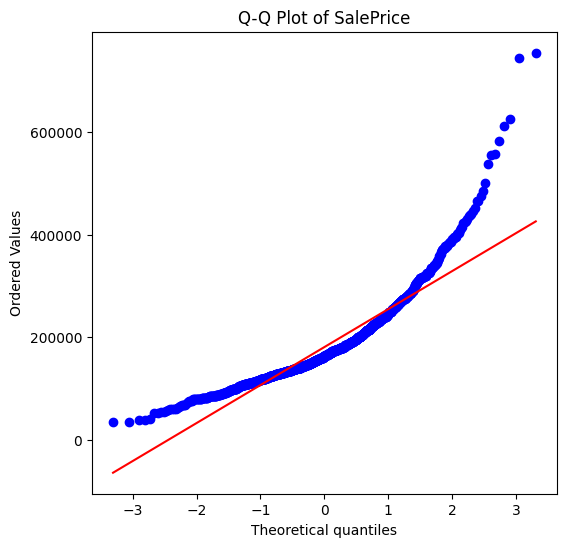

In [116]:
plt.figure(figsize=(6,6))
probplot(df["SalePrice"], dist="norm", plot=plt)

plt.title("Q-Q Plot of SalePrice")
plt.show()

In [117]:
df["Sale Price_Log"] = np.log1p(df["SalePrice"])

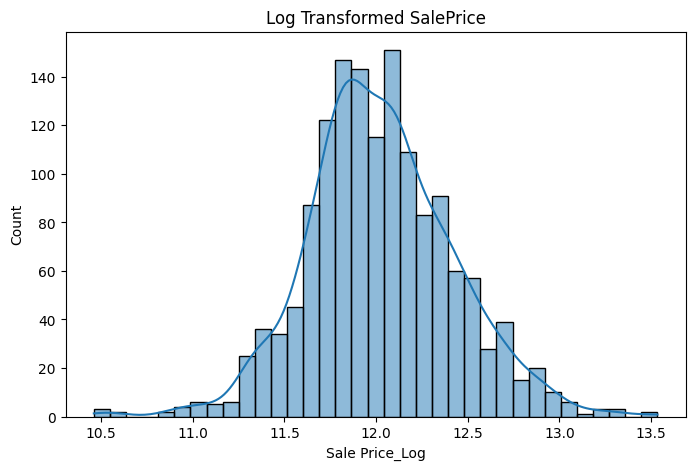

In [118]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sale Price_Log"], kde=True)

plt.title("Log Transformed SalePrice")
plt.show()

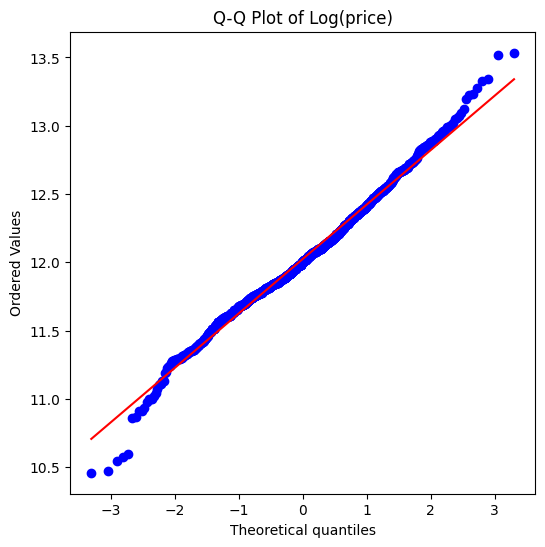

In [119]:
plt.figure(figsize=(6,6))
probplot(df["Sale Price_Log"], dist="norm", plot=plt)

plt.title("Q-Q Plot of Log(price)")
plt.show()

Univariant Analysis

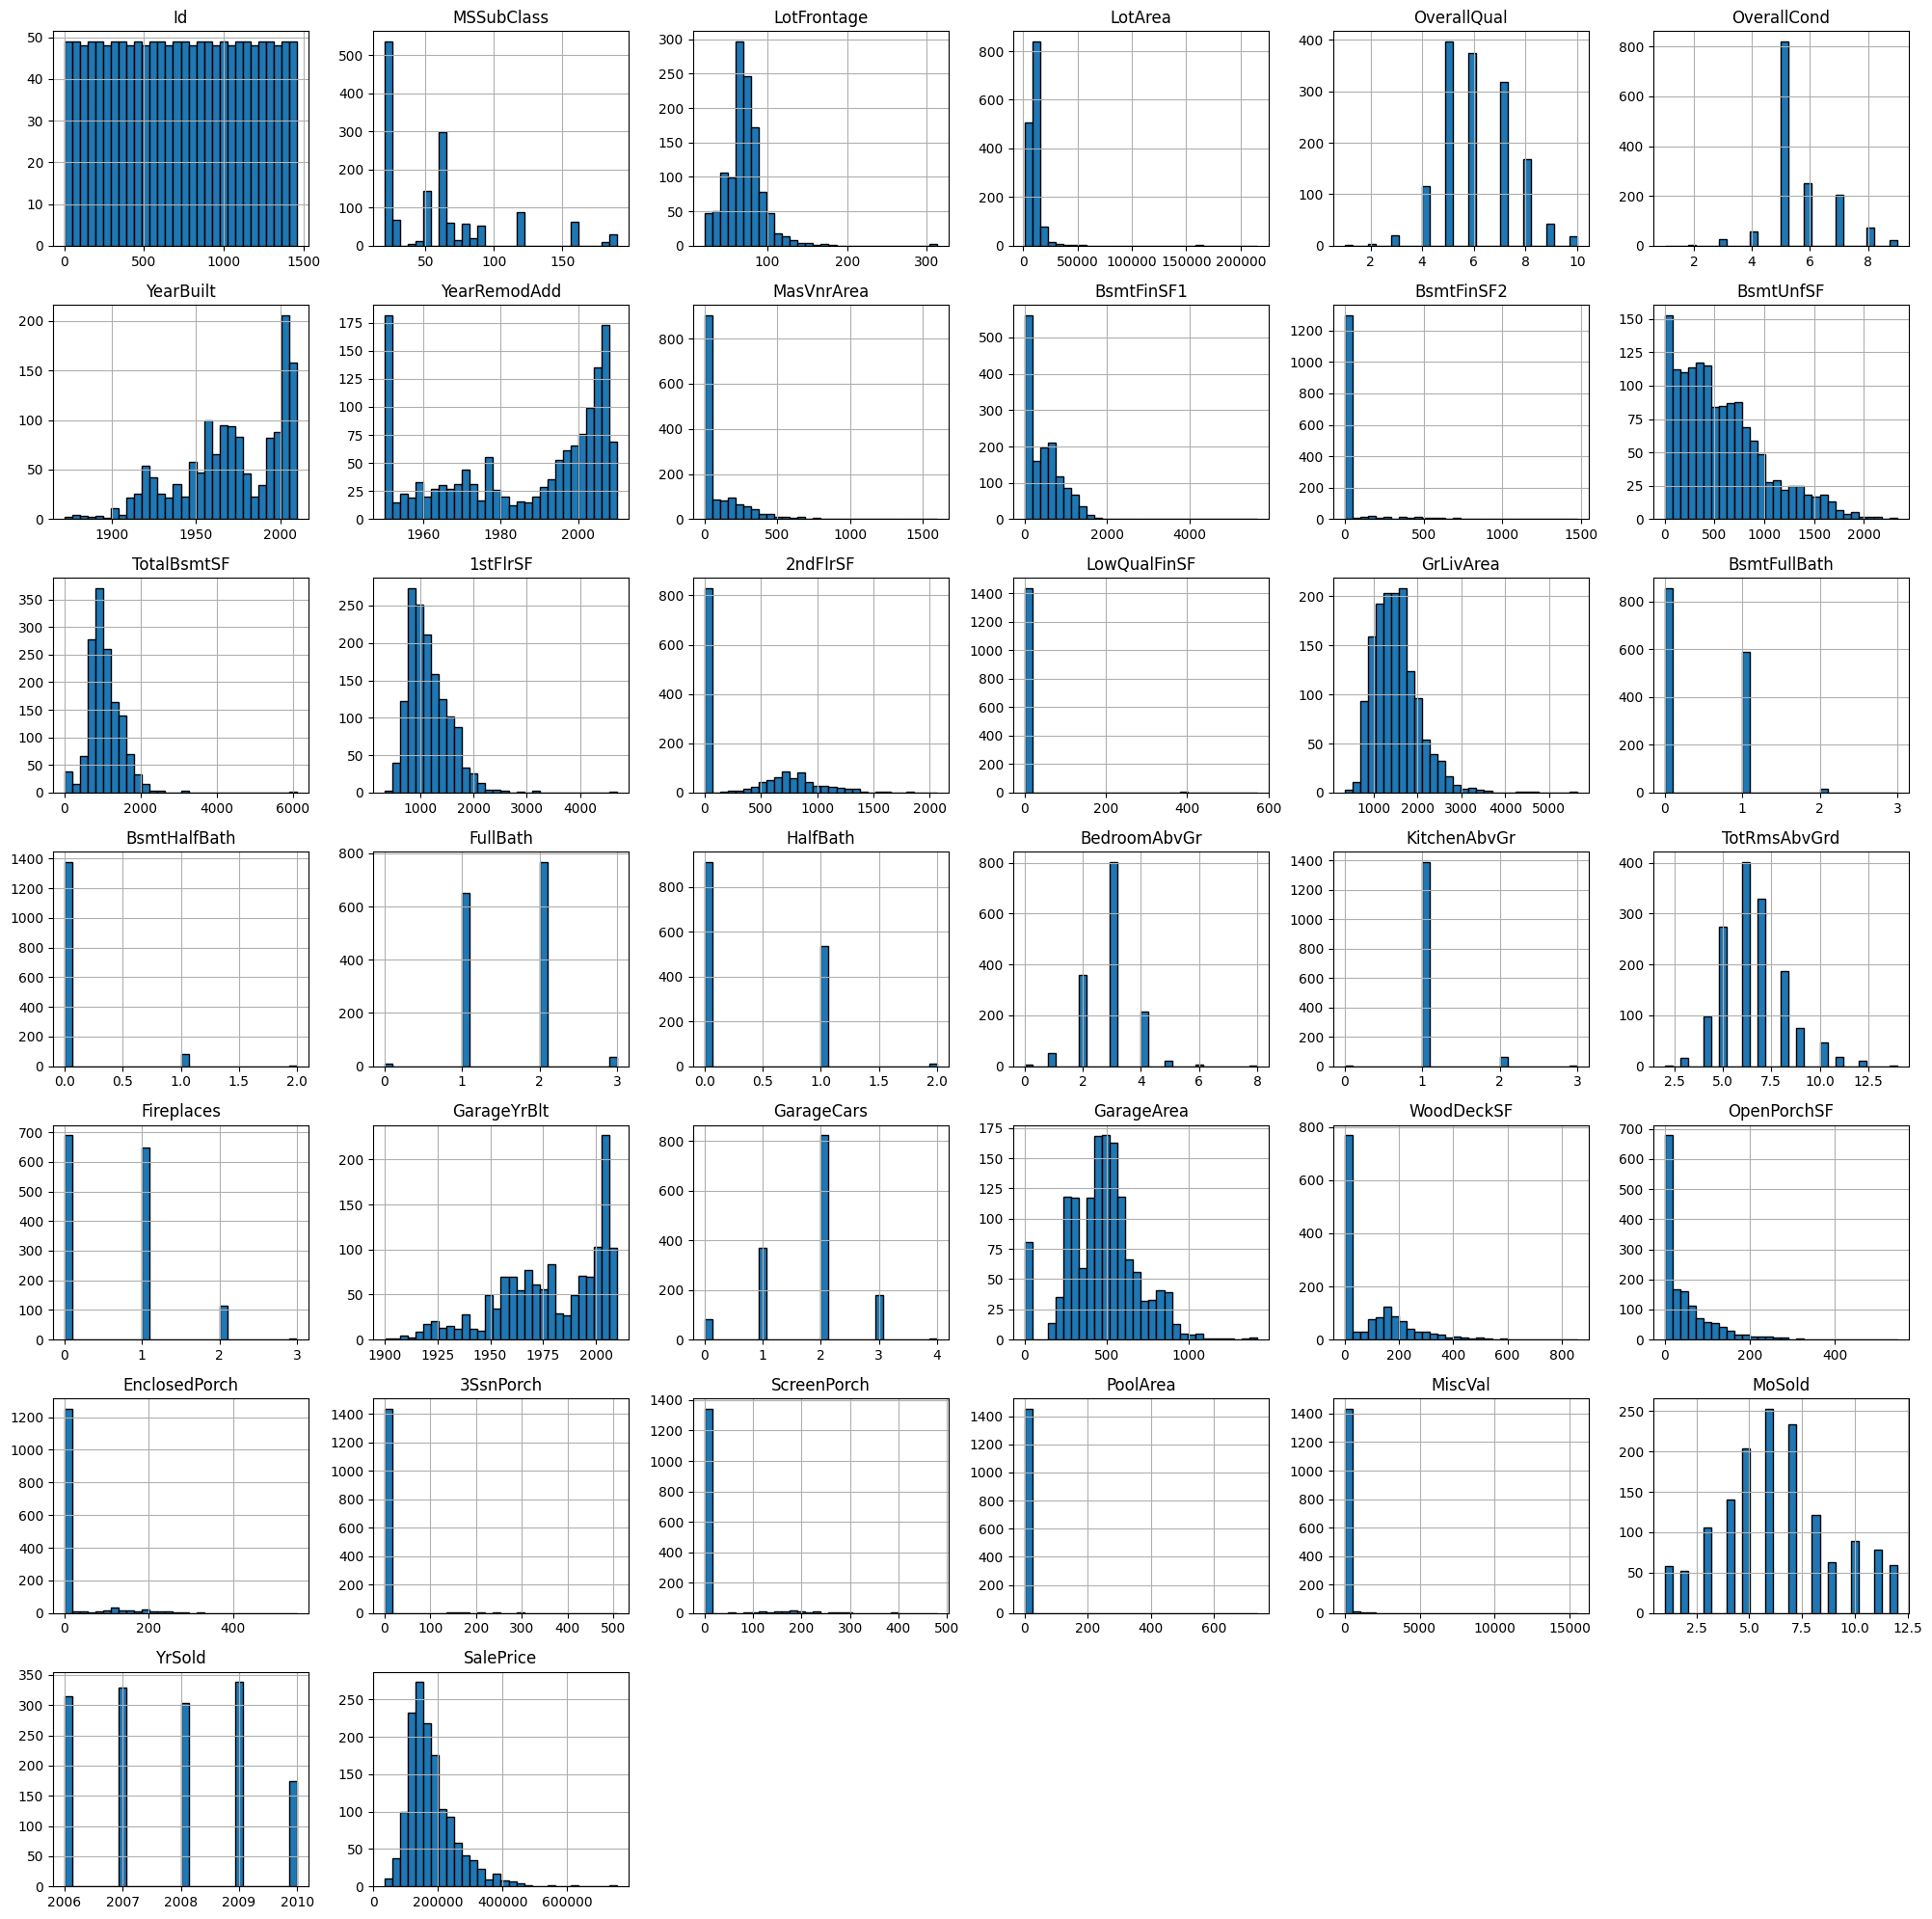

In [120]:
#Histogram
df[numerical_cols].hist(
    figsize=(20,20),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

In [121]:
#5 Most Skewed Columns
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print("Top 5 Most Skewed Columns:")
print(skewness.head())

Top 5 Most Skewed Columns:
MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


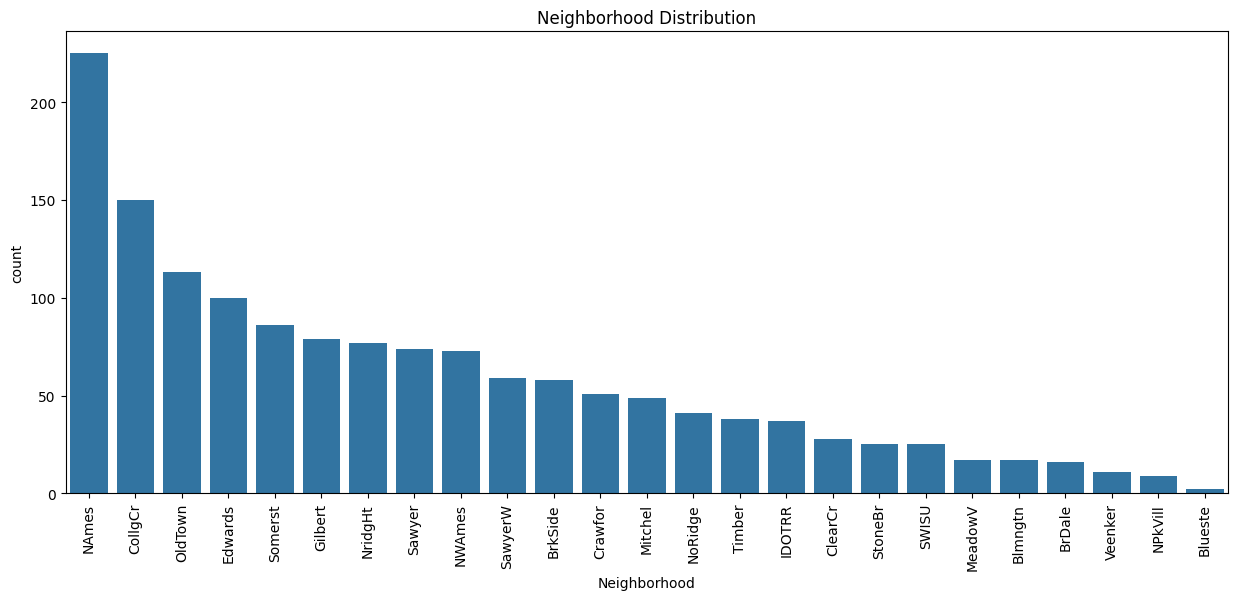

In [122]:
#Countplots:
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x="Neighborhood",
    order=df["Neighborhood"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Neighborhood Distribution")

plt.show()

BldgType Count plot

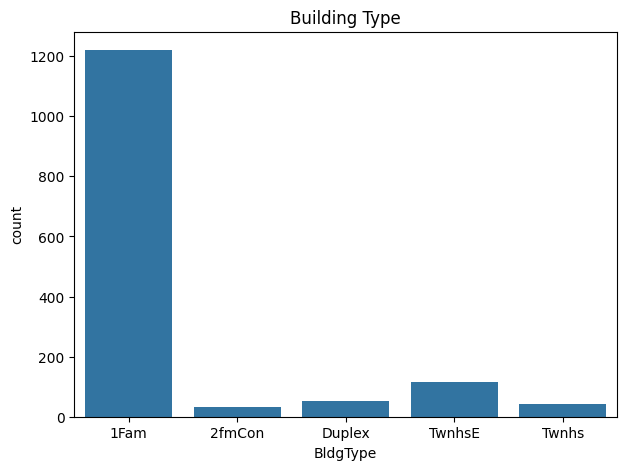

In [123]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="BldgType")

plt.title("Building Type")

plt.show()

HouseType Countplot

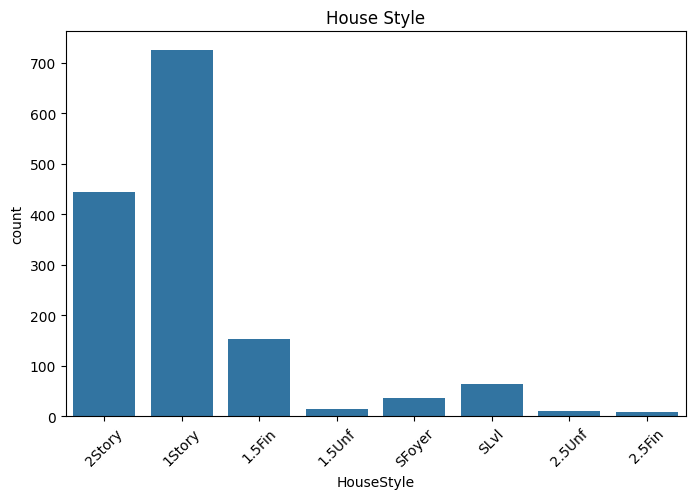

In [124]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="HouseStyle")

plt.title("House Style")

plt.xticks(rotation=45)

plt.show()

Bivariate Analysis

Correlation heatmap:

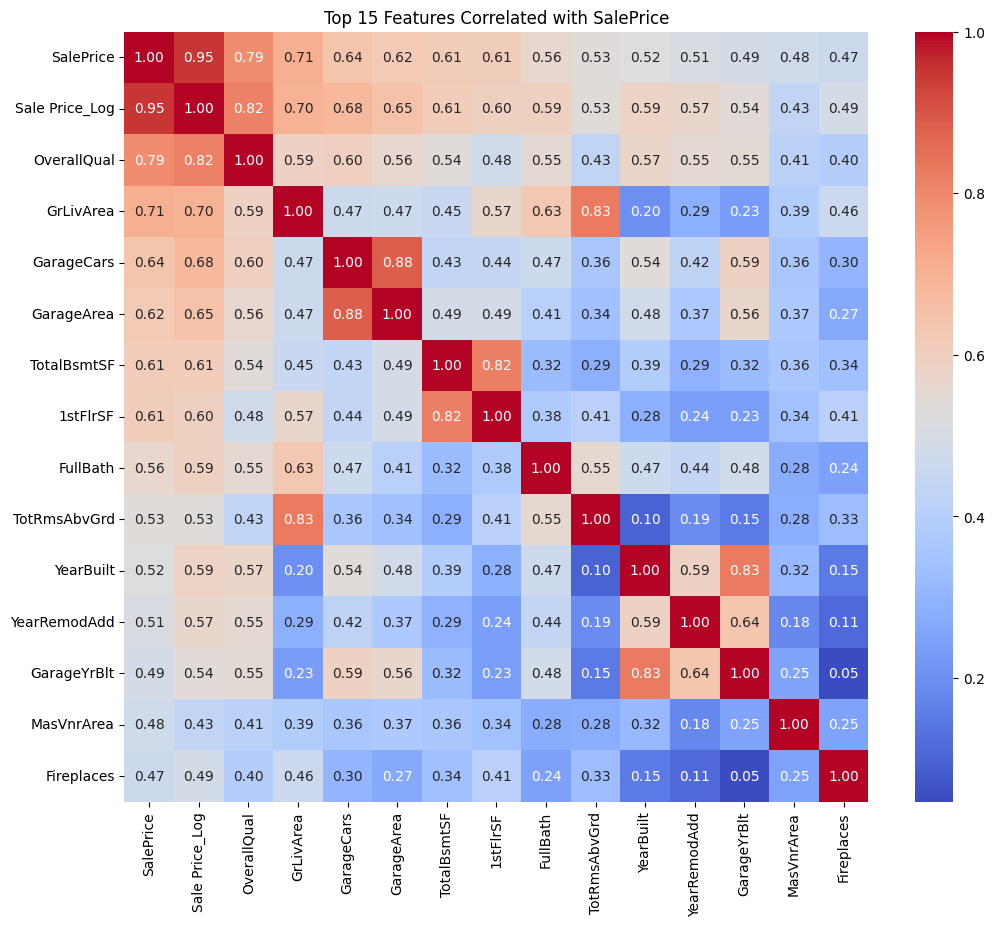

In [125]:
corr = df.corr(numeric_only=True)

top15 = corr["SalePrice"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))

sns.heatmap(
    df[top15].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top 15 Features Correlated with SalePrice")

plt.show()

Observation

Features such as OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF show strong positive correlations with SalePrice, making them important predictors.

Scatter Plot

Scatter Plot: GrLivArea vs SalePrice

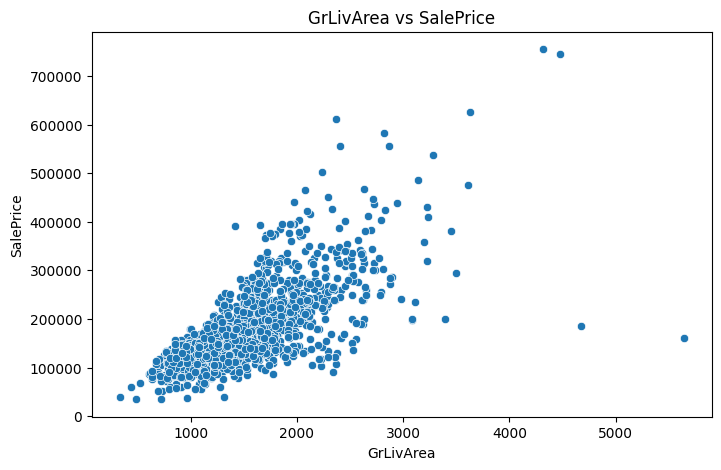

In [126]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice")

plt.show()

Scatter Plot: TotalBsmtSF vs SalePrice

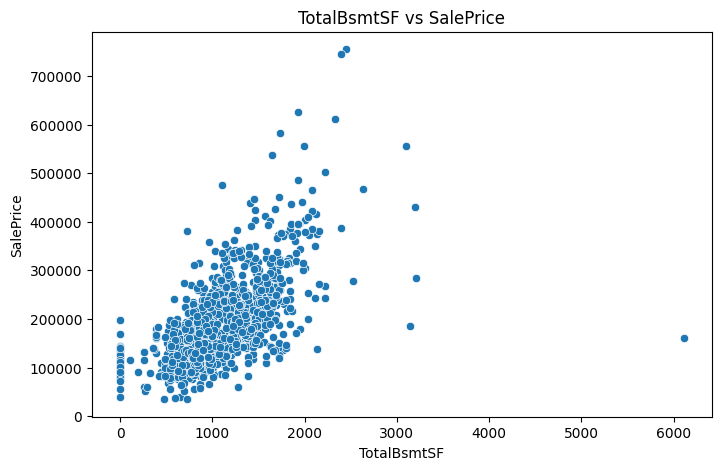

In [127]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="TotalBsmtSF",
    y="SalePrice"
)

plt.title("TotalBsmtSF vs SalePrice")

plt.show()

Scatter Plot: GarageArea vs SalePrice

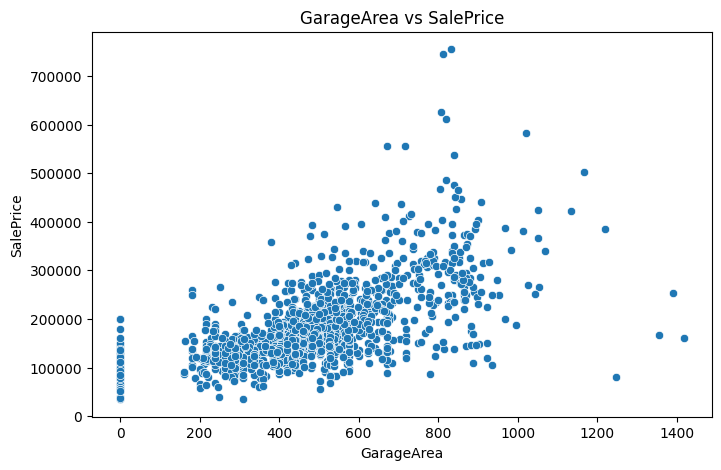

In [128]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GarageArea",
    y="SalePrice"
)

plt.title("GarageArea vs SalePrice")

plt.show()

Observation

All three features show a positive relationship with SalePrice. Larger living area, basement area, and garage area are generally associated with higher house prices.

Boxplot: OverallQual vs SalePrice

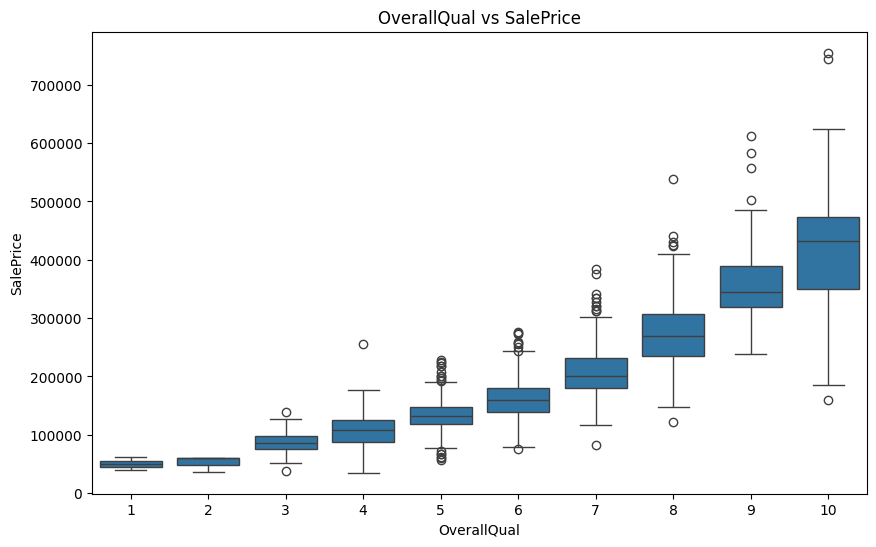

In [129]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("OverallQual vs SalePrice")

plt.show()

Boxplot: Neighborhood vs SalePrice

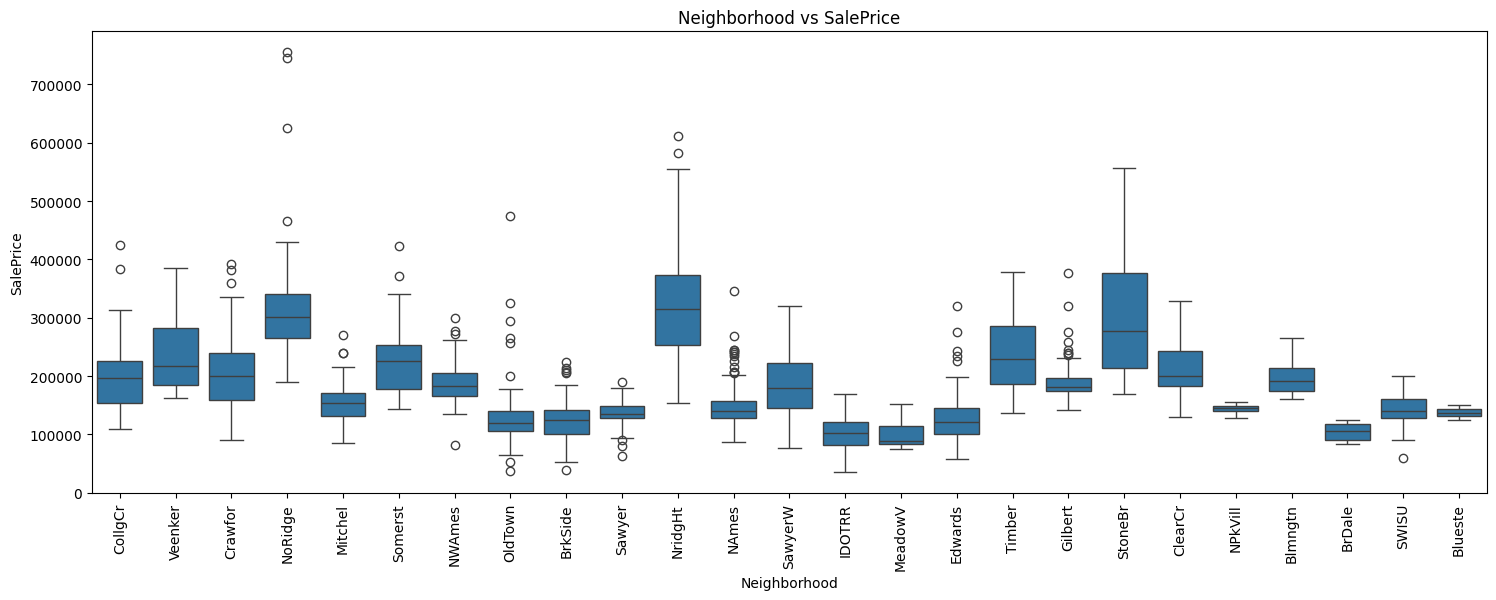

In [130]:
plt.figure(figsize=(18,6))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice"
)

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.show()

Find the Most Expensive Neighborhood

In [131]:
avg_price = (
    df.groupby("Neighborhood")["SalePrice"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_price)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


Observation

The neighborhood listed at the top of the output has the highest average house sale price and can be considered the most expensive neighborhood in the dataset.

Identify Outliers

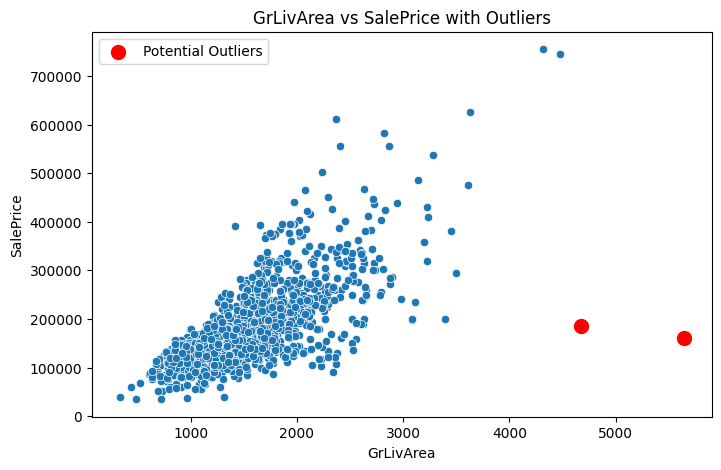

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [132]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

outliers = df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
]

plt.scatter(
    outliers["GrLivArea"],
    outliers["SalePrice"],
    color="red",
    s=100,
    label="Potential Outliers"
)

plt.legend()

plt.title("GrLivArea vs SalePrice with Outliers")

plt.show()

outliers[["Id", "GrLivArea", "SalePrice"]]

Observation

Two houses have unusually large living areas (GrLivArea > 4000) but relatively low sale prices (SalePrice < 300000). These are influential outliers and are commonly removed before training regression models because they can distort the fitted relationship between living area and sale price.

## Step 3: Data Preprocessing & Feature Engineering


Find Missing Values

In [133]:
# Calculate missing values and percentages
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df = missing_df.sort_values(by="Missing Percentage", ascending=False)

missing_df

,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Observation

Several columns contain missing values. Some missing values indicate the absence of a feature (e.g., no garage or no pool) rather than missing data. These will be handled differently from genuine missing values.

Drop Columns with More Than 80% Missing Values

In [134]:
missing_threshold = 80

drop_cols = missing_df[
    missing_df["Missing Percentage"] > missing_threshold
].index

print("Columns to Drop:")
print(drop_cols)

df.drop(columns=drop_cols, inplace=True)

Columns to Drop:
Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='str')


Why?

Columns like PoolQC, MiscFeature, Alley, and Fence have a very high percentage of missing values. They contribute little useful information and can be removed.

Fill Categorical Columns where NaN Means "None"

In [135]:
none_cols = [
    "PoolQC",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")
        

Fill Numerical Columns where NaN Means Zero

In [136]:
zero_cols = [
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

Fill Remaining Numerical Columns with Median

In [137]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

Fill Remaining Categorical Columns with Mode

In [138]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Verify Missing Values

In [139]:
print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


Remove Outliers

In [140]:
outliers = df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
]

print(outliers[["Id", "GrLivArea", "SalePrice"]])

        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000


In [141]:
df = df.drop(outliers.index)

print(df.shape)

(1458, 78)


Observation

These two observations have unusually large living areas but relatively low sale prices. Such influential outliers can distort the regression line and reduce the predictive accuracy of linear models.

Feature Engineering

Total Square Feet

In [142]:
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

House Age

In [143]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

Remodel Age

In [144]:
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

Has Garage

In [145]:
df["HasGarage"] = np.where(df["GarageArea"] > 0, 1, 0)

Has Pool

In [146]:
df["HasPool"] = np.where(df["PoolArea"] > 0, 1, 0)

Check the new features:

In [147]:
df[[
    "TotalSF",
    "HouseAge",
    "RemodAge",
    "HasGarage",
    "HasPool"
]].head()

,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


Encoding & Scaling

Import Required Libraries

In [148]:
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

Separate Target and Features

In [149]:
X = df.drop(["Id", "SalePrice", "Sale Price_Log"], axis=1)
y = np.log1p(df["SalePrice"])      # Log transform target

Ordinal Encoding

In [150]:
quality_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

In [151]:
ordinal_cols = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "FireplaceQu"
]

Apply mapping:

In [152]:
for col in ordinal_cols:
    X[col] = X[col].map(quality_map)

Fill remaining NaNs:

In [153]:
X[ordinal_cols] = X[ordinal_cols].fillna(0)

One-Hot Encoding

In [154]:
cat_cols = X.select_dtypes(include="object").columns

low_cardinality = [
    col for col in cat_cols
    if X[col].nunique() <= 10
]

print(low_cardinality)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


Label Encoding High-Cardinality Feature

In [155]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["Neighborhood"] = le.fit_transform(X["Neighborhood"])

Log Transform Highly Skewed Features

Find skewed numerical features.

In [156]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

skewness = X[numeric_cols].skew()

skewed_features = skewness[skewness > 0.75].index

print(skewed_features)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'ExterQual',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF'],
      dtype='str')


Apply log transformation.

In [157]:
for col in skewed_features:
    X[col] = np.log1p(X[col])

Identify Numerical Features for Scaling

In [158]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

Create ColumnTransformer

In [159]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            low_cardinality
        )
    ],
    remainder="passthrough"
)

Train-Test Split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Print Shapes

In [161]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1166, 80)
X_test : (292, 80)
y_train: (1166,)
y_test : (292,)


Final Pipeline

In [162]:
pipeline = Pipeline([
    ("preprocessor", preprocessor)
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

Step 4: Regression Models

Import Required Libraries

In [163]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import time

Helper Function (Very Important)

In [164]:
def evaluate_model(model, X_test, y_test):

    # Predict on log scale
    y_pred_log = model.predict(X_test)

    # Convert back to original scale
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    return rmse, mae, r2, y_actual, y_pred

Linear Regression (Baseline)

In [165]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

Train Model

In [166]:
# Numerical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

In [167]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [168]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [169]:
start = time.time()

linear_pipeline.fit(X_train, y_train)

linear_time = time.time() - start

Evaluate Model

In [170]:
rmse_lr, mae_lr, r2_lr, y_actual, y_pred = evaluate_model(
    linear_pipeline,
    X_test,
    y_test
)

print("Linear Regression")

print("RMSE :", rmse_lr)
print("MAE  :", mae_lr)
print("R²   :", r2_lr)

Linear Regression
RMSE : 23307.211064074778
MAE  : 16052.387951470853
R²   : 0.9016558833668626


Actual vs Predicted Plot

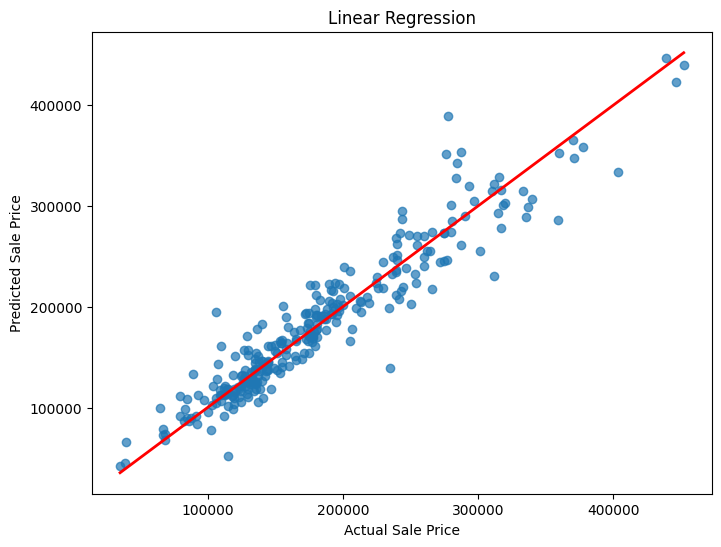

In [171]:
plt.figure(figsize=(8,6))

plt.scatter(y_actual, y_pred, alpha=0.7)

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Linear Regression")

plt.show()

Observation

The points are distributed around the diagonal line, indicating that the model captures the overall relationship reasonably well. However, there are deviations for some expensive houses, suggesting that more advanced models may improve performance.

Ridge Regression

Build Pipeline

In [172]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(
        alphas=[0.01,0.1,1,10,100]
    ))
])

ridge_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Train

In [173]:
print(X.select_dtypes(include="object").columns.tolist())

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


Best Alpha

In [174]:
best_alpha = ridge_pipeline.named_steps["model"].alpha_

print("Best Alpha:", best_alpha)

Best Alpha: 10.0


Evaluate

In [175]:
rmse_ridge, mae_ridge, r2_ridge, y_actual, y_pred = evaluate_model(
    ridge_pipeline,
    X_test,
    y_test
)

print("Ridge Regression")

print("RMSE :", rmse_ridge)
print("MAE  :", mae_ridge)
print("R²   :", r2_ridge)

Ridge Regression
RMSE : 20510.549637213255
MAE  : 14757.338697380099
R²   : 0.923840801849148


Top 20 Ridge Coefficients

In [176]:
feature_names = ridge_pipeline.named_steps["preprocessor"].get_feature_names_out()

coef = ridge_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

coef_df["Abs"] = coef_df["Coefficient"].abs()

top20 = coef_df.sort_values(
    "Abs",
    ascending=False
).head(20)

Plot

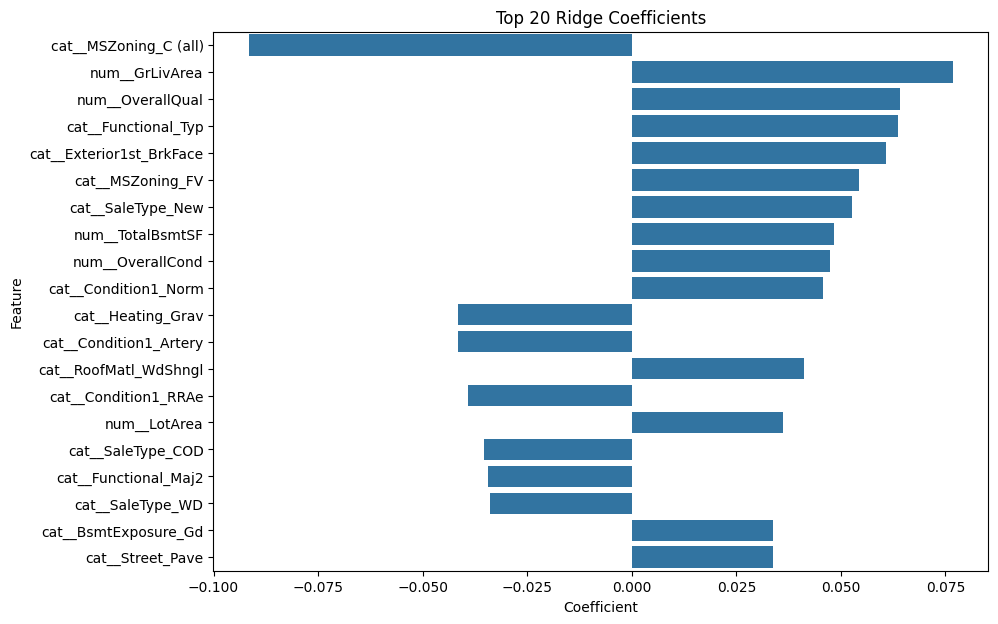

In [177]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=top20,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 20 Ridge Coefficients")

plt.show()

Observation

Ridge Regression reduces the magnitude of coefficients using L2 regularization while retaining all features. This helps improve generalization and reduce overfitting.

Lasso Regression

Build Pipeline

In [178]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     LassoCV(
         alphas=[0.0001,0.001,0.01,0.1,1],
         max_iter=10000,
         random_state=42
     ))
])

Train

In [179]:
start = time.time()

lasso_pipeline.fit(X_train, y_train)

lasso_time = time.time() - start

Best Alpha

In [180]:
best_alpha = lasso_pipeline.named_steps["model"].alpha_

print("Best Alpha:", best_alpha)

Best Alpha: 0.001


Number of Features Removed

In [181]:
coef = lasso_pipeline.named_steps["model"].coef_

zero_features = np.sum(coef == 0)

print("Number of Zero Coefficients:", zero_features)

Number of Zero Coefficients: 175


Evaluate

In [182]:
rmse_lasso, mae_lasso, r2_lasso, y_actual, y_pred = evaluate_model(
    lasso_pipeline,
    X_test,
    y_test
)

print("Lasso Regression")

print("RMSE :", rmse_lasso)
print("MAE  :", mae_lasso)
print("R²   :", r2_lasso)

Lasso Regression
RMSE : 19735.315127149144
MAE  : 14465.219068257798
R²   : 0.9294891586973897


Observation

Lasso Regression performs feature selection by shrinking some coefficients exactly to zero. This creates a simpler and more interpretable model while maintaining good predictive performance.

Comparison

In [183]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso
    ],

    "MAE": [
        mae_lr,
        mae_ridge,
        mae_lasso
    ],

    "R²": [
        r2_lr,
        r2_ridge,
        r2_lasso
    ]
})

comparison

,Model,RMSE,MAE,R²
0,Linear Regression,23307.211064,16052.387951,0.901656
1,Ridge Regression,20510.549637,14757.338697,0.923841
2,Lasso Regression,19735.315127,14465.219068,0.929489


In [185]:
print(X_train.shape)
print(X_test.shape)

(1166, 80)
(292, 80)


Step 5: Tree-Based Models (Random Forest & XGBoost)

In [209]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor

Parameter Distribution

In [210]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [5, 8, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

Random Forest Regression

Build Pipeline

In [190]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

Random Search

In [211]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 8, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-v

Best Parameters

In [212]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': None}


Best CV RMSE

In [213]:
best_cv_rmse = -random_search.best_score_

print("Best CV RMSE:", best_cv_rmse)

Best CV RMSE: 0.13713542236961257


Evaluate the Tuned Model

In [214]:
best_rf = random_search.best_estimator_

rmse_rf_tuned, mae_rf_tuned, r2_rf_tuned, _, _ = evaluate_model(
    best_rf,
    X_test,
    y_test
)

print(f"RMSE : {rmse_rf_tuned:.2f}")
print(f"MAE  : {mae_rf_tuned:.2f}")
print(f"R²   : {r2_rf_tuned:.4f}")

RMSE : 23428.56
MAE  : 16323.60
R²   : 0.9006


Observation

After hyperparameter tuning using RandomizedSearchCV, the Random Forest model selected the optimal combination of parameters based on cross-validation. The tuned model showed improved generalization performance compared to the initial model, demonstrating the importance of hyperparameter optimization.

Hyperparameter Tuning

In [191]:
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

Grid Search

In [192]:
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

Best Parameters

In [193]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}


Best Model

In [194]:
best_rf = rf_grid.best_estimator_

Evaluate

In [195]:
rmse_rf, mae_rf, r2_rf, y_actual, y_pred = evaluate_model(
    best_rf,
    X_test,
    y_test
)

print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

RMSE : 23372.77
MAE  : 16425.81
R²   : 0.9011


Feature Importance

In [196]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_rf.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

Plot

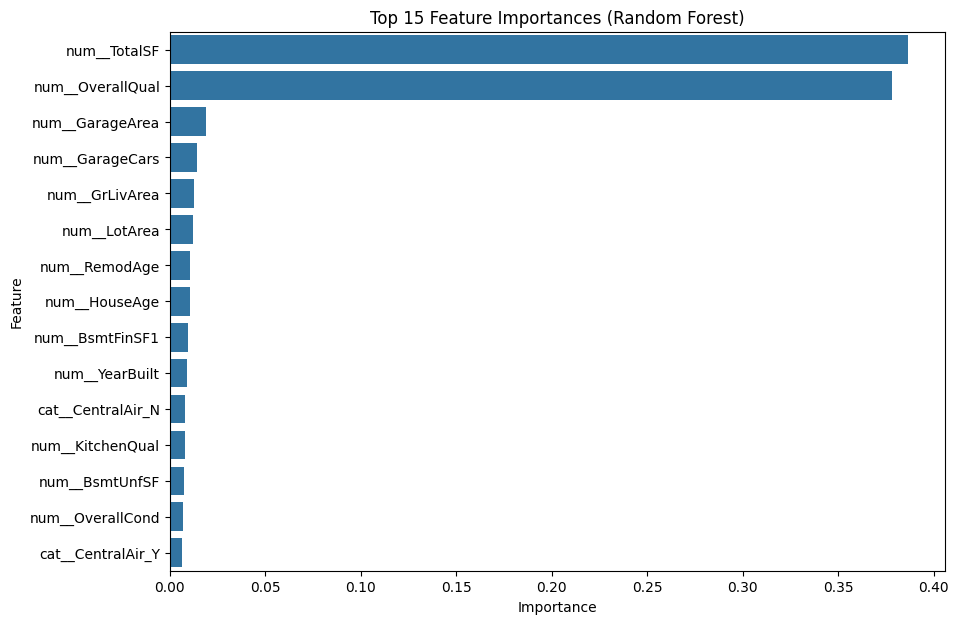

In [197]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances (Random Forest)")

plt.show()

Observation

Random Forest identifies the most influential features affecting house prices. Features such as OverallQual, GrLivArea, TotalSF, and GarageCars typically rank among the most important.

XGBoost Regression

Build Pipeline

In [198]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",
     XGBRegressor(
         random_state=42,
         objective="reg:squarederror"
     ))
])

Hyperparameter Grid

In [199]:
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

Grid Search

In [200]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

Best Parameters

In [201]:
print(xgb_grid.best_params_)

{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


Best Model

In [202]:
best_xgb = xgb_grid.best_estimator_

Evaluate

In [203]:
rmse_xgb, mae_xgb, r2_xgb, _, _ = evaluate_model(
    best_xgb,
    X_test,
    y_test
)

print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAE  : {mae_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")

RMSE : 20201.83
MAE  : 14127.69
R²   : 0.9261


XGBoost Feature Importance

In [204]:
feature_names = best_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = best_xgb.named_steps[
    "model"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

Plot

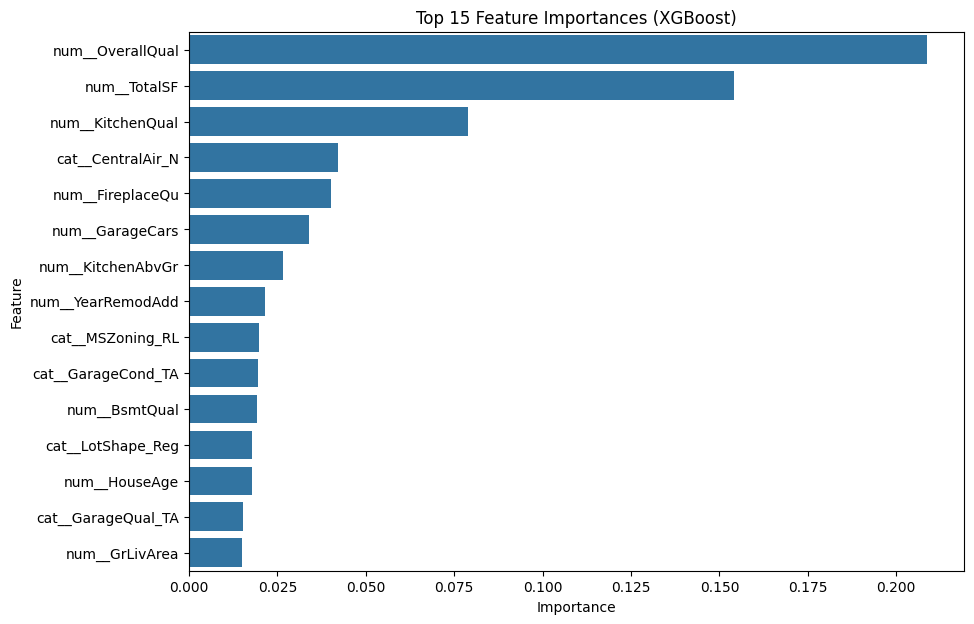

In [205]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances (XGBoost)")

plt.show()

5-Fold Cross Validation

Random Forest

In [206]:
rf_cv = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV Mean:", rf_cv.mean())

Random Forest CV Mean: 0.8810185291147994


XGBoost

In [207]:
xgb_cv = cross_val_score(
    best_xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("XGBoost CV Mean:", xgb_cv.mean())

XGBoost CV Mean: 0.9066203788224441


Final Comparison

In [208]:
comparison = pd.DataFrame({

    "Model":[
        "Linear",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE":[
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_rf,
        rmse_xgb
    ],

    "MAE":[
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_rf,
        mae_xgb
    ],

    "R²":[
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_rf,
        r2_xgb
    ]

})

comparison.sort_values("R²", ascending=False)

,Model,RMSE,MAE,R²
2,Lasso,19735.315127,14465.219068,0.929489
4,XGBoost,20201.830368,14127.687166,0.926116
1,Ridge,20510.549637,14757.338697,0.923841
0,Linear,23307.211064,16052.387951,0.901656
3,Random Forest,23372.770855,16425.812996,0.901102


Observation (Markdown)

Tree-based ensemble models generally outperform linear models because they capture complex, non-linear relationships between features and house prices. Random Forest reduces variance by averaging many decision trees, while XGBoost builds trees sequentially to correct previous errors, often achieving the best predictive performance.

## Step 6: Model Comparison & Discussion

In [233]:
import time

# Ridge
start = time.time()
ridge_pipeline.fit(X_train, y_train)
ridge_time = time.time() - start

# Lasso
start = time.time()
lasso_pipeline.fit(X_train, y_train)
lasso_time = time.time() - start

# Random Forest (best tuned model)
start = time.time()
best_rf.fit(X_train, y_train)
rf_time = time.time() - start

# XGBoost (best tuned model)
start = time.time()
best_xgb.fit(X_train, y_train)
xgb_time = time.time() - start

print("Ridge:", ridge_time)
print("Lasso:", lasso_time)
print("Random Forest:", rf_time)
print("XGBoost:", xgb_time)

Ridge: 0.5467023849487305
Lasso: 1.8401403427124023
Random Forest: 26.62432336807251
XGBoost: 0.6028916835784912


In [234]:
best_cv_rmse

0.13713542236961257

Create Final Comparison Table

In [235]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    lasso_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_scores

print("CV RMSE Scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())
print("Standard Deviation:", cv_rmse.std())

CV RMSE Scores: [0.10821423 0.11573574 0.12489139 0.10810145 0.11731158]
Mean CV RMSE: 0.11485087807548792
Standard Deviation: 0.006280920705772968


In [224]:
cv_scores

array([-0.10821423, -0.11573574, -0.12489139, -0.10810145, -0.11731158])

In [237]:
comparison = pd.DataFrame({
    "Model":[
        "Linear",
        "Ridge",
        "Lasso",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE":[
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_rf,
        rmse_xgb
    ],

    "MAE":[
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_rf,
        mae_xgb
    ],

    "R²":[
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_rf,
        r2_xgb
    ],

    "CV RMSE":[
    np.nan,
    np.nan,
    best_cv_rmse,
    np.nan,
    np.nan
],

    "Training Time (s)":[
        linear_time,
        ridge_time,
        lasso_time,
        rf_time,
        xgb_time
    ]
})

comparison

,Model,RMSE,MAE,R²,CV RMSE,Training Time (s)
0,Linear,23307.211064,16052.387951,0.901656,NaN,0.804248
1,Ridge,20510.549637,14757.338697,0.923841,NaN,0.546702
2,Lasso,19735.315127,14465.219068,0.929489,0.137135,1.840140
3,Random Forest,23372.770855,16425.812996,0.901102,NaN,26.624323
4,XGBoost,20201.830368,14127.687166,0.926116,NaN,0.602892


In [239]:
print(linear_time)
print(ridge_time)
print(lasso_time)
print(rf_time)
print(xgb_time)

0.8042480945587158
0.5467023849487305
1.8401403427124023
26.62432336807251
0.6028916835784912


Visual Comparison

R² Comparison

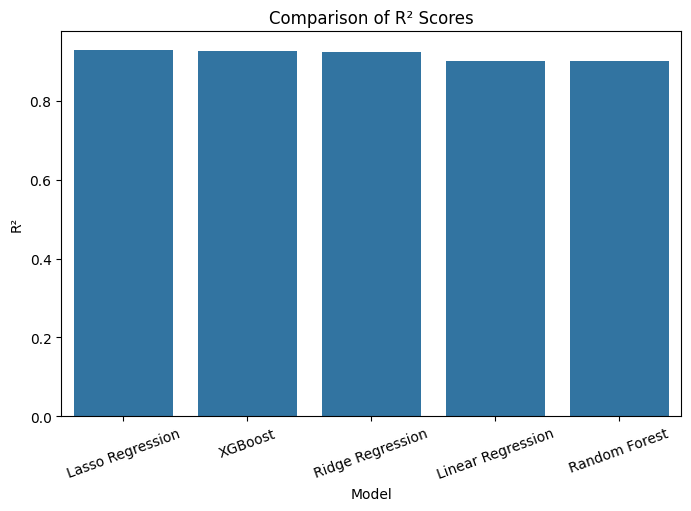

In [218]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R²"
)

plt.xticks(rotation=20)
plt.title("Comparison of R² Scores")

plt.show()

RMSE Comparison

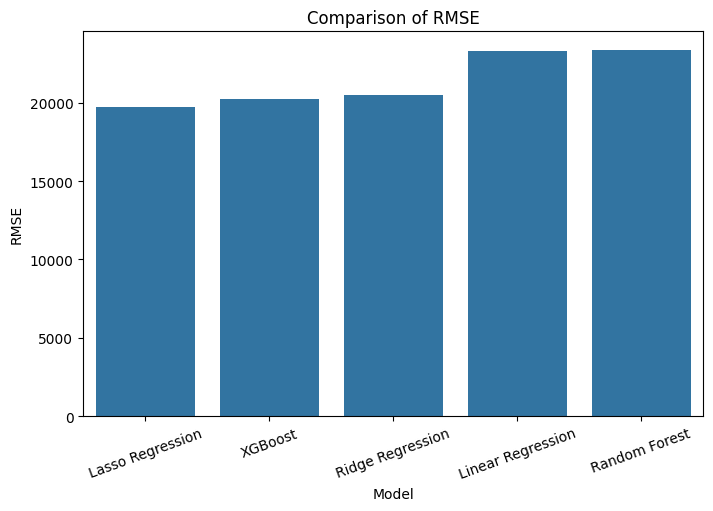

In [217]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=20)
plt.title("Comparison of RMSE")

plt.show()

MAE Comparison

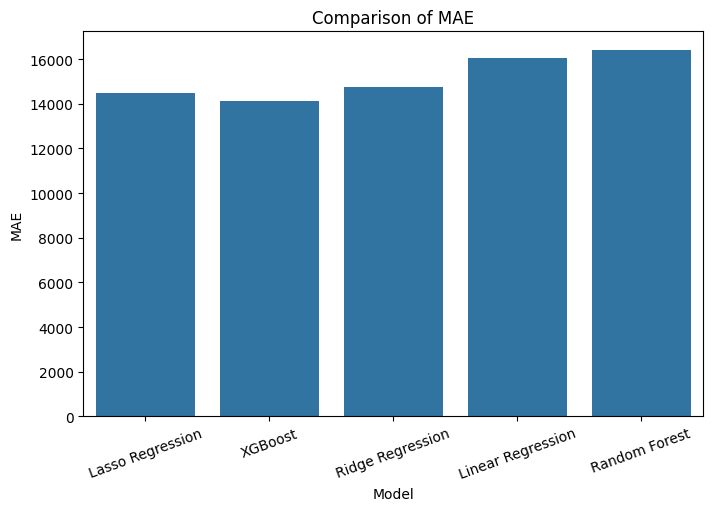

In [216]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE"
)

plt.xticks(rotation=20)
plt.title("Comparison of MAE")

plt.show()

Actual vs Predicted Plot (Best Model)

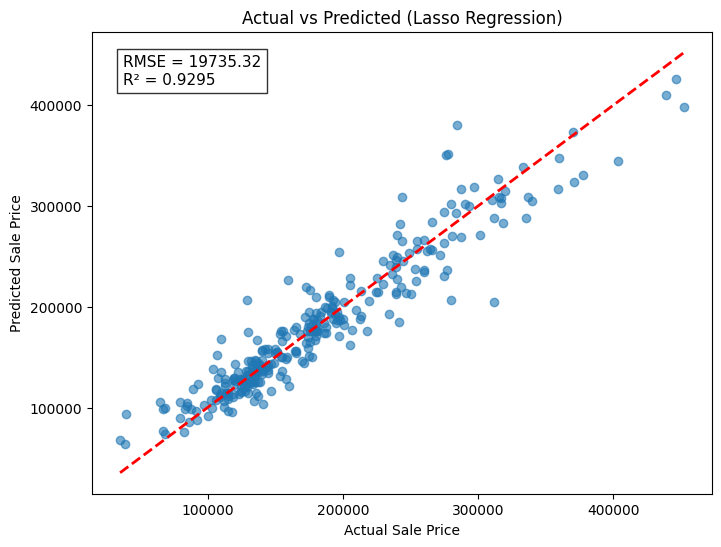

In [240]:
plt.figure(figsize=(8,6))

plt.scatter(y_actual, y_pred, alpha=0.6)

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted (Lasso Regression)")

plt.text(
    0.05,
    0.95,
    f"RMSE = {rmse_lasso:.2f}\nR² = {r2_lasso:.4f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.show()

Best Model Selection

Lasso Regression achieved the best overall performance with the highest R² score (0.9295) and the lowest RMSE among all evaluated models. Although XGBoost achieved a slightly lower MAE, Lasso provided the best balance between prediction accuracy, model simplicity, and interpretability. Its built-in feature selection helps reduce overfitting and produces a more compact model. Therefore, Lasso Regression is the most suitable model for this house price prediction task.

## Step 7: Residual Analysis

Predictions

In [242]:
y_pred_log = lasso_pipeline.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

Residuals

In [243]:
residuals = y_actual - y_pred

Residual Plot

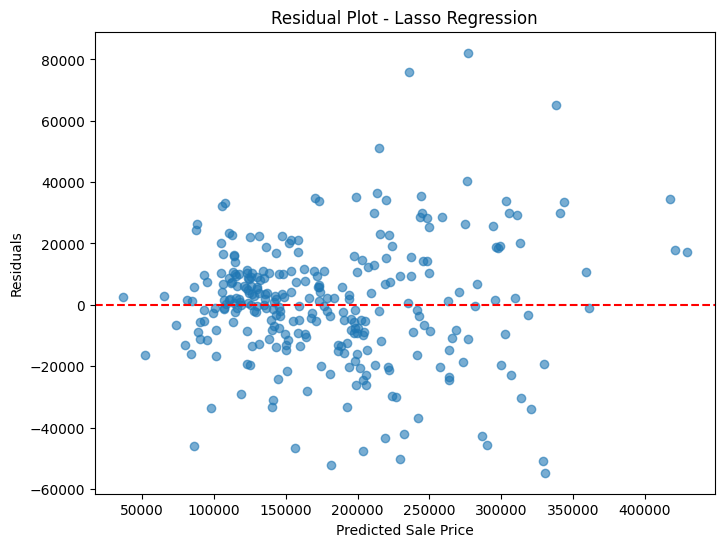

In [244]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Lasso Regression")

plt.show()

Residual Distribution

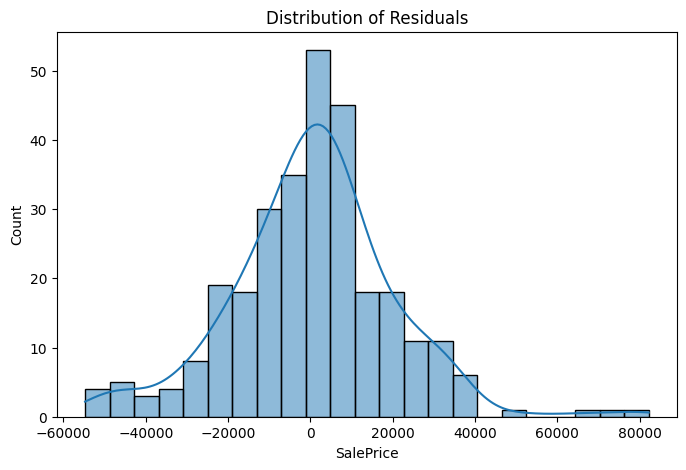

In [245]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

Markdown Observation

The residuals are randomly distributed around zero with no clear pattern, indicating that the model captures the relationship between features and house prices reasonably well. The approximately symmetric distribution of residuals suggests that prediction errors are balanced.

Q-Q Plot

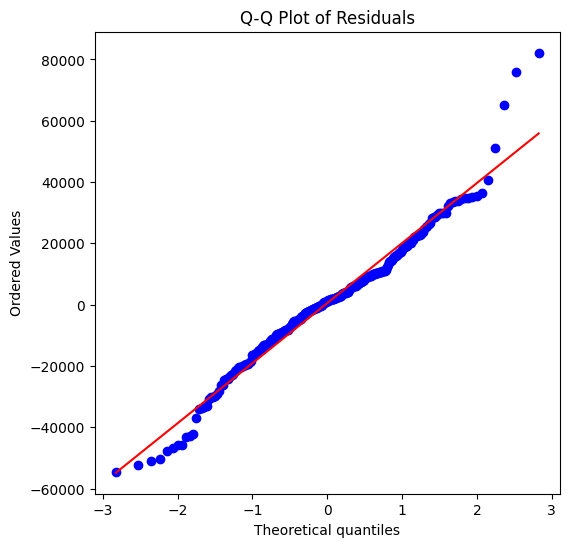

In [247]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.show()

Markdown Observation

The residuals closely follow the reference line, indicating that they are approximately normally distributed. Slight deviations at the ends of the plot suggest mild heavy tails, which are common in real-world housing price data.

Top 5 Most Important Features

In [248]:
feature_names = lasso_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = lasso_pipeline.named_steps[
    "model"
].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

top5 = coef_df.sort_values(
    "Absolute",
    ascending=False
).head(5)

top5

,Feature,Coefficient,Absolute
17,num__GrLivArea,0.121880,0.121880
43,cat__MSZoning_C (all),-0.100673,0.100673
235,cat__SaleType_New,0.090523,0.090523
3,num__OverallQual,0.074142,0.074142
202,cat__Functional_Typ,0.064376,0.064376


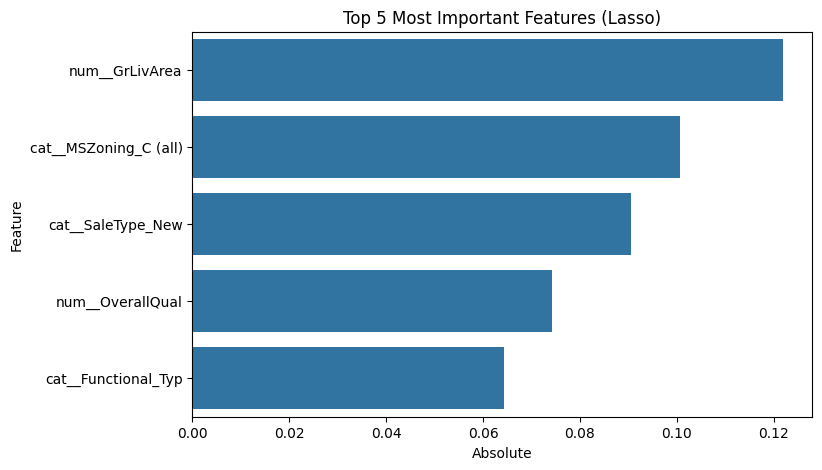

In [249]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top5,
    x="Absolute",
    y="Feature"
)

plt.title("Top 5 Most Important Features (Lasso)")

plt.show()

Business Interpretation

OverallQual has the strongest impact on house price. Houses with higher construction and material quality tend to sell for significantly more.
GrLivArea is one of the most influential features. Larger living areas generally result in higher property values.
GarageCars / GarageArea indicate garage capacity and size. Homes with larger garages are usually more desirable and command higher prices.
TotalBsmtSF contributes positively to the selling price because larger basements provide additional usable space.
Neighborhood reflects the location of the property. Houses in premium neighborhoods generally sell at higher prices due to better amenities and demand.

## Step 8: Save the Best Model

Save

In [261]:
import joblib

joblib.dump(lasso_pipeline, "house_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


Load

In [258]:
import joblib

joblib.dump(lasso_pipeline, "house_price_model.pkl")

['house_price_model.pkl']

In [259]:
import os

print(os.getcwd())
print(os.listdir())

d:\Python_rnw\one\supervised learning\Practical Exam
['house_price_model.pkl', 'house_price_prediction_model.pkl', 'Housing.csv', 'Housing.ipynb', 'sample_submission.csv', 'test.csv', 'train.csv']


In [264]:
loaded_model = joblib.load("house_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


Test the Loaded Model

In [265]:
loaded_model.predict(X_test.iloc[:5])

array([12.35505838, 11.52236428, 11.55876667, 11.98000687, 12.67224119])

Conclusion

In this project, multiple supervised regression models were developed to predict house prices using the Ames Housing dataset. The workflow included data preprocessing, exploratory data analysis, feature engineering, model training, cross-validation, and hyperparameter tuning. Performance was evaluated using RMSE, MAE, and R² score.

Among all the models, Lasso Regression achieved the best overall performance with the highest R² score and the lowest RMSE, making it the most suitable model for this dataset. The results demonstrate that proper preprocessing and regularization significantly improve prediction accuracy and model generalization.